In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer # new
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline # new
from sklearn.feature_selection import SelectKBest,chi2 # new
from sklearn.tree import DecisionTreeClassifier

In [3]:
df = pd.read_csv('train.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Let's Plan

In [5]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [6]:
# Step 1 -> train/test/split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['Survived']),
                                                 df['Survived'],
                                                 test_size=0.2,
                                                random_state=42)

In [7]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S


In [8]:
y_train.sample(5)

502    0
94     0
52     1
466    0
335    0
Name: Survived, dtype: int64

In [9]:
# imputation transformer

trf1 = ColumnTransformer([
    ('impute_age',SimpleImputer(),[2]),
    ('impute_embarked',SimpleImputer(strategy='most_frequent'),[6])
],remainder='passthrough')

# We mandatorily use column indices i.e. [2] and [6] instead of column names (like 'Age' and 'Embarked') because when chaining multiple transformers in a pipeline, intermediate steps output NumPy arrays which have no column name headers

In [12]:
# one hot encoding
trf2 = ColumnTransformer([
    ('ohe_sex_embarked',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[1,6]) # not dropping first column as Decision Tree isn't a linear model
],remainder='passthrough')

# Both columns i.e. 'Sex' and 'Embarked' can be processed by a single OneHotEncoder here because the data is no longer fragmented into separate variables, and missing values have already been resolved by trf1

In [18]:
# Scaling

trf3 = ColumnTransformer([
    ('scale',MinMaxScaler(),slice(0,10)) # since the data obtained in previous step will have 10 columns
])

# MinMaxScaler is used because it bounds numerical features strictly within a non-negative [0, 1] range, seamlessly aligning them with the binary 0 and 1 scale of the one-hot encoded columns. Crucially, maintaining strictly non-negative values is required for downstream steps like Chi-Square feature selection (SelectKBest(score_func=chi2)), which will crash on negative numbers—a problem StandardScaler causes by centering data around a mean of zero

In [20]:
# Feature selection

trf4 = SelectKBest(score_func=chi2,k=8)

In [21]:
# train the model

trf5 = DecisionTreeClassifier()

# Create Pipeline

In [23]:
pipe = Pipeline([
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3),
    ('trf4',trf4),
    ('trf5',trf5)
])
# Pipeline() accepts a list of 2-element tuples where each tuple follows the format ('step_name', transformer_or_estimator_object)

## Pipeline may or may not contain the step of training the model through our pipeline - it depends on us!

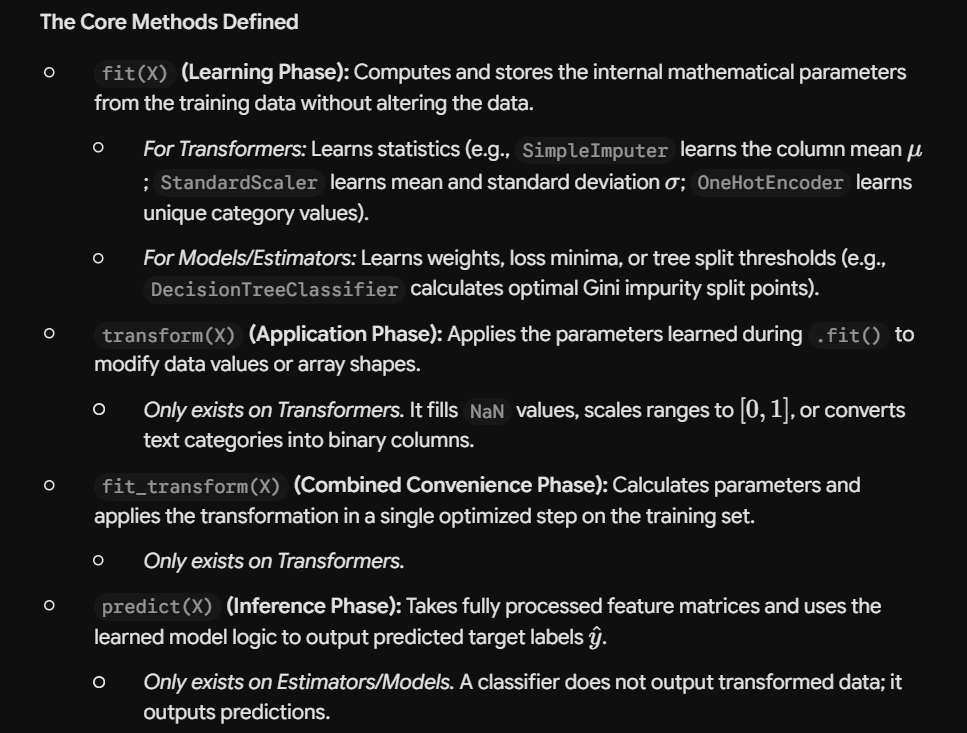
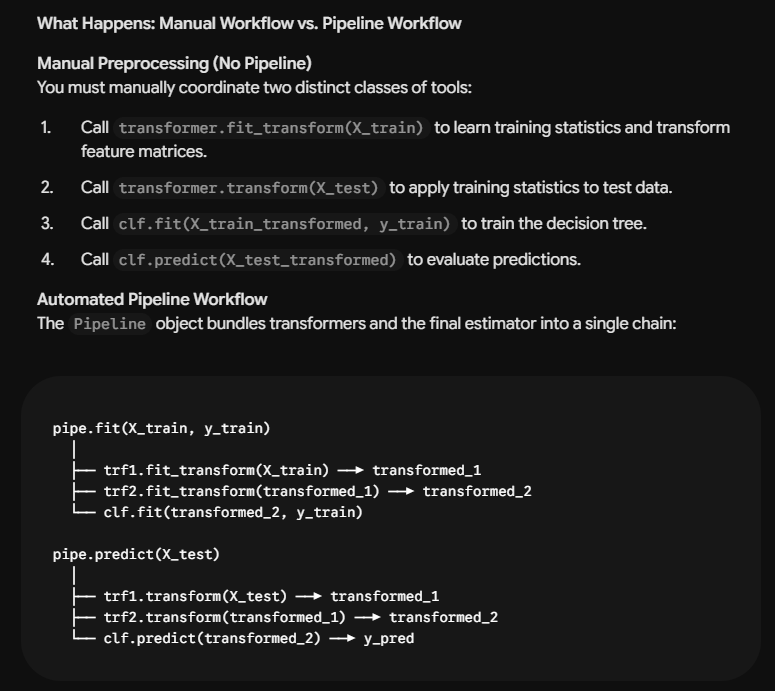
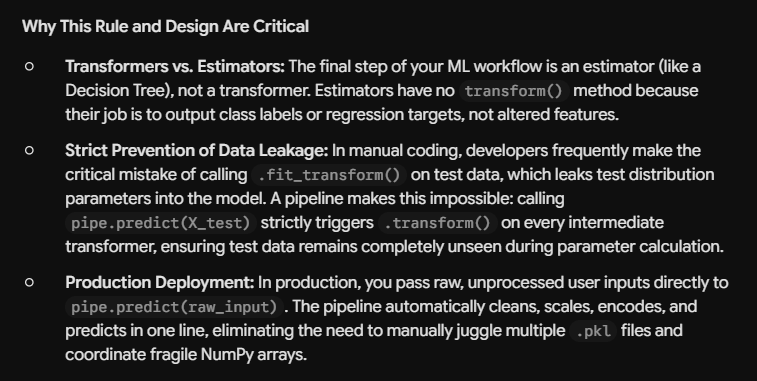

# Pipeline Vs make_pipeline

Pipeline requires naming of steps, make_pipeline does not.

(Same applies to ColumnTransformer vs make_column_transformer)

In [28]:
# Alternate Syntax

pipe = make_pipeline(trf1,trf2,trf3,trf4,trf5)

In [29]:
# train

pipe.fit(X_train,y_train)

,steps,"[('columntransformer-1', ...), ('columntransformer-2', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('impute_age', ...), ('impute_embarked', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Explore the Pipeline

In [46]:
# Code here

pipe.named_steps

{'columntransformer-1': ColumnTransformer(remainder='passthrough',
                   transformers=[('impute_age', SimpleImputer(), [2]),
                                 ('impute_embarked',
                                  SimpleImputer(strategy='most_frequent'),
                                  [6])]),
 'columntransformer-2': ColumnTransformer(remainder='passthrough',
                   transformers=[('ohe_sex_embarked',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  [1, 6])]),
 'columntransformer-3': ColumnTransformer(transformers=[('scale', MinMaxScaler(), slice(0, 10, None))]),
 'selectkbest': SelectKBest(k=8, score_func=<function chi2 at 0x000001E3F83DC700>),
 'decisiontreeclassifier': DecisionTreeClassifier()}

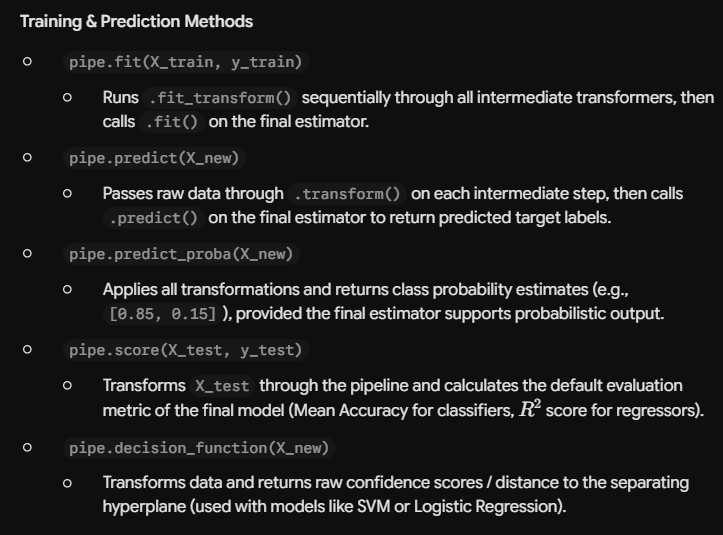

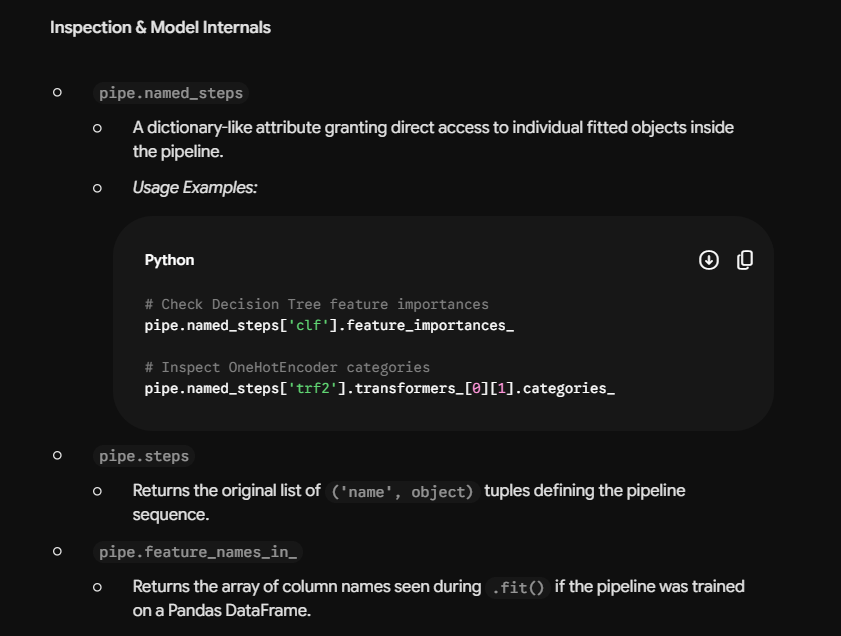

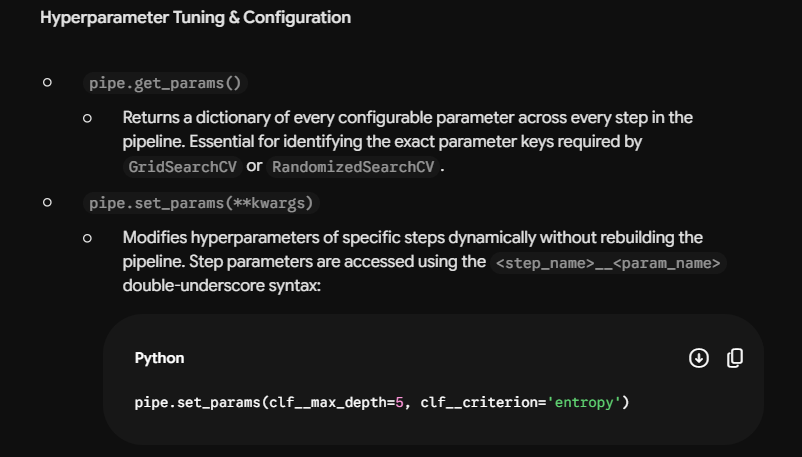

In [47]:
# Display Pipeline

from sklearn import set_config
set_config(display='diagram')

In [48]:
# Predict
y_pred = pipe.predict(X_test)

In [49]:
y_pred

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0])

In [50]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6256983240223464

# Cross Validation using Pipeline

In [52]:
# cross validation using cross_val_score
from sklearn.model_selection import cross_val_score
print(cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean())

0.6391214419383433


# GridSearch using Pipeline

In [54]:
# gridsearchcv
params = {
    'decisiontreeclassifier__max_depth':[1,2,3,4,5,None]
}

In [55]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'decisiontreeclassifier__max_depth': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('impute_age', ...), ('impute_embarked', ...)]"


In [56]:
grid.best_score_

np.float64(0.6391214419383433)

In [57]:
grid.best_params_

{'decisiontreeclassifier__max_depth': 2}

# Exporting the Pipeline

In [58]:
# export
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))